## Paper Replicating - Vision Transformer
 - https://arxiv.org/abs/2010.11929
 - using pytorch

In [1]:
## Get setup
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.6.0
torchvision version: 0.21.0


In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

/Users/sachinmurali/anaconda3/envs/transformers/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [4]:
## Get data
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                      destination="pizza_steak_sushi")

image_path

[INFO] data/pizza_steak_sushi directory exists, skipping download.


PosixPath('data/pizza_steak_sushi')

In [5]:
train_dir = image_path/"train"
test_dir = image_path/"test"

train_dir , test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [6]:
#set up data loader
from torchvision import transforms
IMAGE_SIZE = 224

manual_transform = transforms.Compose([
    transforms.Resize(size=(IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor()   
])

manual_transform

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)

In [7]:
BATCH_SIZE = 32

train_data_loader, test_data_loader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                  test_dir=test_dir,
                                                  transform=manual_transform,
                                                  batch_size=BATCH_SIZE
                                                  )


len(train_data_loader), len(test_data_loader), class_names

(8, 3, ['pizza', 'steak', 'sushi'])

In [8]:
## Visualize a dingle image
# get the first batch of 32
image_batch, label_batch = next(iter(train_data_loader))

In [9]:
# get a a singel image and label

image, label = image_batch[0] , label_batch[0]

image.shape , label.shape

(torch.Size([3, 224, 224]), torch.Size([]))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

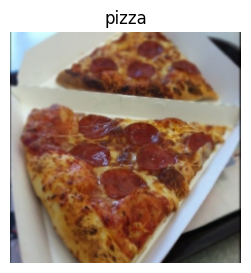

In [10]:
# plot the image with matplot lib
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))

plt.imshow(image.permute(1,2,0))

plt.title(class_names[label.item()])

plt.axis("off")


In [11]:
image

tensor([[[0.5098, 0.7294, 0.8196,  ..., 0.5961, 0.4157, 0.2118],
         [0.5098, 0.7294, 0.8196,  ..., 0.5882, 0.4118, 0.2157],
         [0.5098, 0.7294, 0.8196,  ..., 0.5882, 0.4118, 0.2118],
         ...,
         [0.2745, 0.3922, 0.4431,  ..., 0.4431, 0.3216, 0.1725],
         [0.2706, 0.3882, 0.4392,  ..., 0.4431, 0.3255, 0.1804],
         [0.2745, 0.3922, 0.4431,  ..., 0.4510, 0.3333, 0.1843]],

        [[0.6275, 0.8627, 0.9725,  ..., 0.6353, 0.4510, 0.2431],
         [0.6275, 0.8627, 0.9725,  ..., 0.6275, 0.4471, 0.2471],
         [0.6275, 0.8627, 0.9725,  ..., 0.6275, 0.4431, 0.2431],
         ...,
         [0.3020, 0.4157, 0.4627,  ..., 0.4471, 0.3255, 0.1765],
         [0.3020, 0.4157, 0.4627,  ..., 0.4471, 0.3294, 0.1843],
         [0.3059, 0.4235, 0.4706,  ..., 0.4549, 0.3373, 0.1882]],

        [[0.6235, 0.8627, 0.9843,  ..., 0.6353, 0.4471, 0.2392],
         [0.6235, 0.8627, 0.9843,  ..., 0.6353, 0.4471, 0.2431],
         [0.6235, 0.8627, 0.9843,  ..., 0.6353, 0.4471, 0.

In [12]:
height = 224 #H
width = 224  #W
color_channel = 3 #C
patch_size = 16 # P

# calculate the number off patchs
# N = HW / P²
num_of_patchs = int((height * width) / patch_size**2)

num_of_patchs # N

196

In [13]:
# Input shape H*W*C
embedding_layer_input_shape = (height , width , color_channel)
# Output shape
embedding_layer_output_shape =  (num_of_patchs , (patch_size**2 * color_channel))

print(f"Inputs shape : {embedding_layer_input_shape}")
print(f"Output shape : {embedding_layer_output_shape}")

Inputs shape : (224, 224, 3)
Output shape : (196, 768)


In [14]:
image

tensor([[[0.5098, 0.7294, 0.8196,  ..., 0.5961, 0.4157, 0.2118],
         [0.5098, 0.7294, 0.8196,  ..., 0.5882, 0.4118, 0.2157],
         [0.5098, 0.7294, 0.8196,  ..., 0.5882, 0.4118, 0.2118],
         ...,
         [0.2745, 0.3922, 0.4431,  ..., 0.4431, 0.3216, 0.1725],
         [0.2706, 0.3882, 0.4392,  ..., 0.4431, 0.3255, 0.1804],
         [0.2745, 0.3922, 0.4431,  ..., 0.4510, 0.3333, 0.1843]],

        [[0.6275, 0.8627, 0.9725,  ..., 0.6353, 0.4510, 0.2431],
         [0.6275, 0.8627, 0.9725,  ..., 0.6275, 0.4471, 0.2471],
         [0.6275, 0.8627, 0.9725,  ..., 0.6275, 0.4431, 0.2431],
         ...,
         [0.3020, 0.4157, 0.4627,  ..., 0.4471, 0.3255, 0.1765],
         [0.3020, 0.4157, 0.4627,  ..., 0.4471, 0.3294, 0.1843],
         [0.3059, 0.4235, 0.4706,  ..., 0.4549, 0.3373, 0.1882]],

        [[0.6235, 0.8627, 0.9843,  ..., 0.6353, 0.4471, 0.2392],
         [0.6235, 0.8627, 0.9843,  ..., 0.6353, 0.4471, 0.2431],
         [0.6235, 0.8627, 0.9843,  ..., 0.6353, 0.4471, 0.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

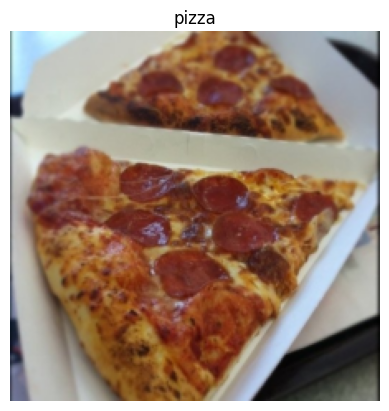

In [15]:
import matplotlib.pyplot as plt

plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis('off')

In [16]:
image.shape

torch.Size([3, 224, 224])

In [17]:
image_permuted = image.permute(1,2,0)

image_permuted.shape

torch.Size([224, 224, 3])

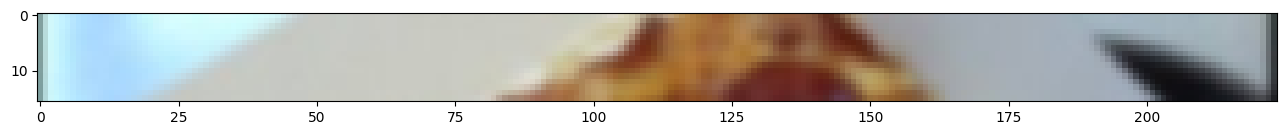

In [18]:
plt.figure(figsize=(16,16))
plt.imshow(image_permuted[:16, :, :])

In [19]:
img_size = 224
patch_size = 16

num_of_patchs = img_size / patch_size

num_of_patchs

14.0

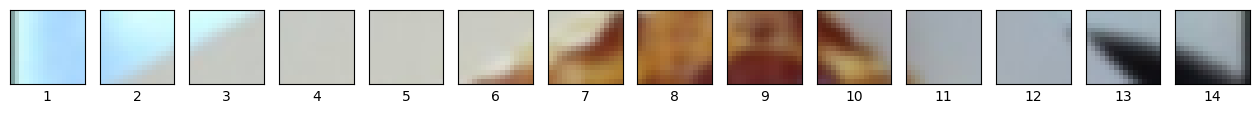

In [20]:
fig, axis = plt.subplots(nrows=1,
                         ncols=img_size // patch_size,
                         figsize = (patch_size, patch_size),
                         sharex=True,
                         sharey=True)



for i, patch in enumerate(range(0,img_size, patch_size)):
    axis[i].imshow(image_permuted[:16, patch:patch+patch_size, :])
    axis[i].set_xlabel(i+1)
    axis[i].set_xticks([])
    axis[i].set_yticks([])

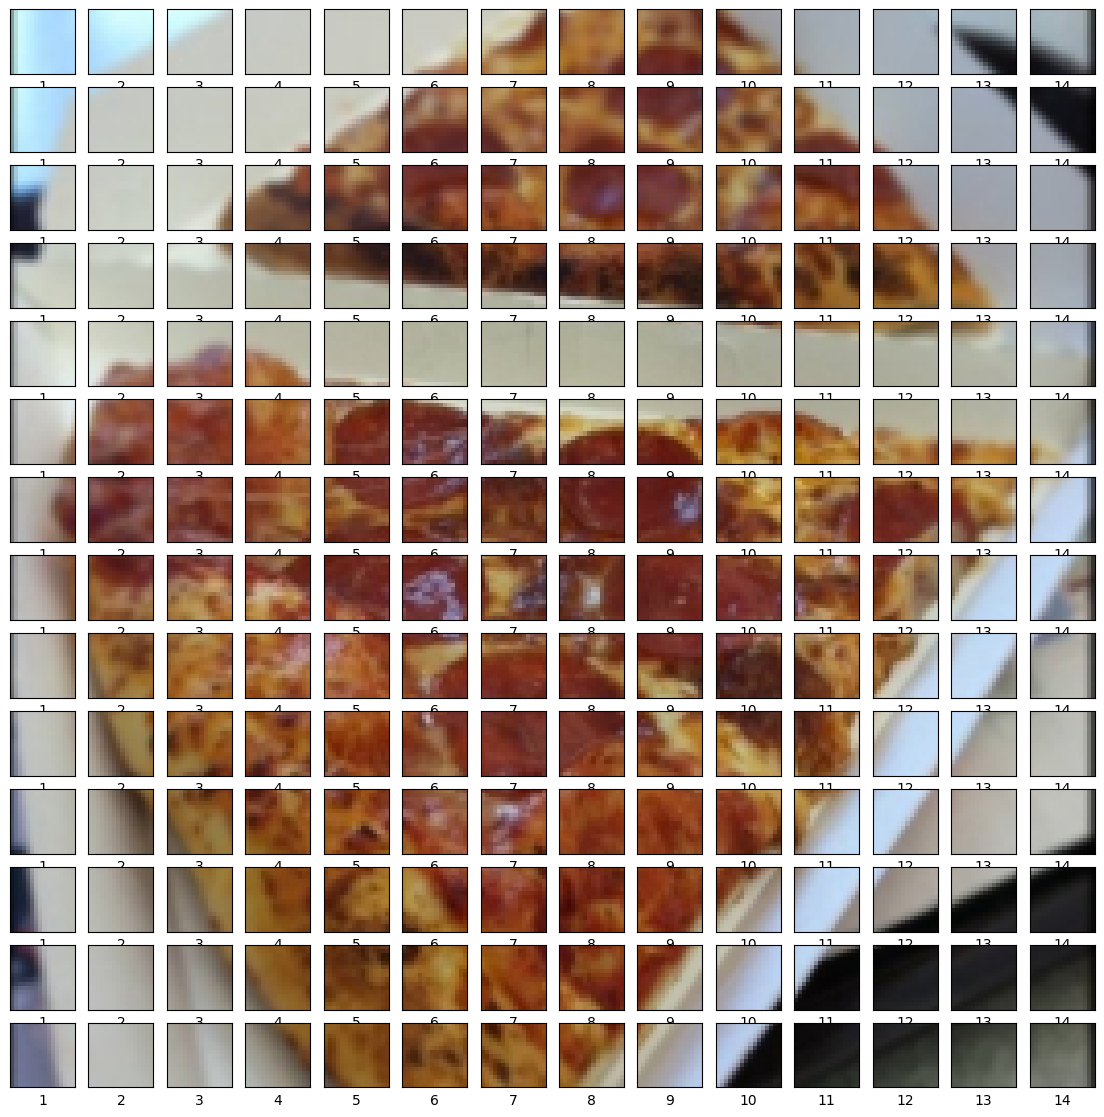

In [21]:
fig, axis = plt.subplots(nrows=img_size // patch_size,
                         ncols=img_size // patch_size,
                         figsize = (num_of_patchs, num_of_patchs),
                         sharex=True,
                         sharey=True)



for i, patch_height in enumerate(range(0,img_size, patch_size)):
    for j, patch_width in enumerate(range(0,img_size, patch_size)):

        axis[i,j].imshow(image_permuted[patch_height:patch_height+patch_size,
                                        patch_width:patch_width+patch_size, :])
        axis[i,j].set_xlabel(j+1)
        axis[i,j].set_xticks([])
        axis[i,j].set_yticks([])

In [22]:
# Create patch's using CNN
from torch import nn

patch_size = 16

conv2d = nn.Conv2d(in_channels=3, # color channel
                   out_channels=768 ,# D
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

conv2d


Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

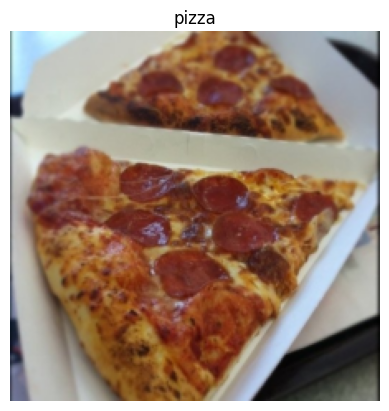

In [23]:
# view a ingle imaage
plt.imshow(image.permute(1,2,0))
plt.title(class_names[label])
plt.axis('off')

In [24]:
image.shape, image.unsqueeze(0).shape

(torch.Size([3, 224, 224]), torch.Size([1, 3, 224, 224]))

In [25]:
image_out_conv = conv2d(image.unsqueeze(0))

image_out_conv.shape

torch.Size([1, 768, 14, 14])

In [26]:
flat = nn.Flatten(start_dim=2)

flattened_image = flat(image_out_conv)

In [27]:
flattened_image.shape

torch.Size([1, 768, 196])

In [28]:
# make erything a class

class PathEmbedd(nn.Module):
    def __init__(self, in_channel:int = 3 , patch_size:int = 16, embed_dim : int = 768): # 768 for ViT BAse
        super().__init__()
        # create a layer, tuen image into embedded path
        self.patcher = nn.Conv2d(in_channels=in_channel, out_channels=embed_dim, kernel_size=patch_size, stride=patch_size, padding=0)
        # now lets flatten, our patch embed into sequence
        self.flatten = nn.Flatten(start_dim=2, end_dim=3)
        self.patch_size = patch_size
        
    def forward(self, x):
        # create an assertion about the input image shape
        image_resolution = x.shape[-1]
        assert image_resolution % self.patch_size == 0 , "Input image must be divisibe by patch size"
        
        #perform forward pass
        x_patcher = self.patcher(x)
        x_flatten = self.flatten(x_patcher)
        
        return x_flatten.permute(0,2,1)
        
        
        
        
        


In [29]:
torch.manual_seed(42)

pachify =  PathEmbedd(in_channel=3, patch_size=16, embed_dim=768)

# let pass an image with batch dimension
batch_image = image.unsqueeze(0)

batch_image.shape

patch_embedded_image = pachify(batch_image)

In [30]:
patch_embedded_image.shape

torch.Size([1, 196, 768])

In [31]:
batch_size = patch_embedded_image.shape[0]
embedded_dim = patch_embedded_image.shape[-1]

batch_size,  embedded_dim

(1, 768)

In [32]:
# create a class token embedding (D)
class_token = nn.Parameter(torch.ones(size=(batch_size,1,embedded_dim), requires_grad=True))

class_token.shape

torch.Size([1, 1, 768])

In [33]:
# append the class token to path embed

path_embed_to_class_embed = torch.cat((class_token, patch_embedded_image), dim=1)

path_embed_to_class_embed.shape

torch.Size([1, 197, 768])

In [34]:
path_embed_to_class_embed

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.9032,  0.3330, -0.3661,  ...,  0.7184, -0.2987,  0.3316],
         [-0.9093,  0.2406, -0.1989,  ...,  0.7273, -0.4479,  0.2529],
         ...,
         [-0.2082,  0.0509, -0.1318,  ...,  0.1872, -0.0656,  0.0580],
         [-0.3790,  0.1076, -0.1787,  ...,  0.2668, -0.0791,  0.0841],
         [-0.3916,  0.0858, -0.2287,  ...,  0.3402, -0.1093,  0.0851]]],
       grad_fn=<CatBackward0>)

In [35]:
bad_image = torch.rand(size=(1,224,224))

path_embed_to_class_embed

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.9032,  0.3330, -0.3661,  ...,  0.7184, -0.2987,  0.3316],
         [-0.9093,  0.2406, -0.1989,  ...,  0.7273, -0.4479,  0.2529],
         ...,
         [-0.2082,  0.0509, -0.1318,  ...,  0.1872, -0.0656,  0.0580],
         [-0.3790,  0.1076, -0.1787,  ...,  0.2668, -0.0791,  0.0841],
         [-0.3916,  0.0858, -0.2287,  ...,  0.3402, -0.1093,  0.0851]]],
       grad_fn=<CatBackward0>)

In [36]:
# putting it al together
torch.manual_seed(42)

patch_size = 16

# Image tensor shape
print(f"Iage shape : {image.shape}")

height, width = image.shape[1] , image.shape[2]


# add batch dim to image
x = image.unsqueeze(0)
x.shape

# create a patch embedding layer
patch_embedded_layer = PathEmbedd(in_channel=3, patch_size=patch_size, embed_dim=768)

# pass the input x tghrough the path embed layer

patch_embedding = patch_embedded_layer(x)

patch_embedding.shape

# create clas embedding toke
batch_size = patch_embedding.shape[0]
embedding_dim = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.ones(size=(batch_size, 1 , embedded_dim)), requires_grad=True)
class_token.shape

# prepend the class token to pathc embedding
patch_embed_class_token = torch.cat((class_token, patch_embedding), dim=1)

patch_embed_class_token.shape

# create position embedding and add it to the tok
num_of_patch = int((height*width) / patch_size ** 2) 
position_embed = nn.Parameter(torch.ones(size=(batch_size, num_of_patch + 1 , embedded_dim)))

position_embed.shape

patch_postion_embed = patch_embed_class_token + position_embed

patch_postion_embed.shape

Iage shape : torch.Size([3, 224, 224])


torch.Size([1, 197, 768])

In [37]:
patch_postion_embed

tensor([[[2.0000, 2.0000, 2.0000,  ..., 2.0000, 2.0000, 2.0000],
         [0.0968, 1.3330, 0.6339,  ..., 1.7184, 0.7013, 1.3316],
         [0.0907, 1.2406, 0.8011,  ..., 1.7273, 0.5521, 1.2529],
         ...,
         [0.7918, 1.0509, 0.8682,  ..., 1.1872, 0.9344, 1.0580],
         [0.6210, 1.1076, 0.8213,  ..., 1.2668, 0.9209, 1.0841],
         [0.6084, 1.0858, 0.7713,  ..., 1.3402, 0.8907, 1.0851]]],
       grad_fn=<AddBackward0>)

In [38]:
a = nn.Parameter(torch.ones(size=(2,3)))
b= torch.ones(size=(2,3))
a, b

(Parameter containing:
 tensor([[1., 1., 1.],
         [1., 1., 1.]], requires_grad=True),
 tensor([[1., 1., 1.],
         [1., 1., 1.]]))

In [39]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim:int = 768, num_heads:int = 12, attn_dropout = 0):
        super().__init__()
        self.layer_norm = nn.LayerNorm(normalized_shape=embedded_dim)
        self.msa = nn.MultiheadAttention(embed_dim=embedded_dim, num_heads=num_heads, dropout=attn_dropout, batch_first=True)
        
    def forward(self, x):
        x = self.layer_norm(x)
        atten_out , _ = self.msa(query=x,key=x,value=x,need_weights=False)
        return atten_out

In [40]:
multi_head_attn_block = MultiHeadAttention()
multi_head_attn_block

MultiHeadAttention(
  (layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (msa): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
)

In [41]:
patch_image_to_mas_block = multi_head_attn_block(patch_postion_embed)

patch_image_to_mas_block.shape, patch_postion_embed.shape

(torch.Size([1, 197, 768]), torch.Size([1, 197, 768]))

In [42]:
from torchvision.ops import MLP

mlp_block = MLP(in_channels=embedded_dim, hidden_channels=[3072,embedded_dim], norm_layer=lambda num_features: nn.LayerNorm(num_features), activation_layer=nn.GELU, dropout=0.1)

In [43]:
mlp_block

MLP(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=3072, out_features=768, bias=True)
  (5): Dropout(p=0.1, inplace=False)
)

In [44]:
patch_image_to_mlp_block = mlp_block(patch_image_to_mas_block)


In [45]:
patch_image_to_mas_block.shape , patch_image_to_mlp_block.shape

(torch.Size([1, 197, 768]), torch.Size([1, 197, 768]))

In [46]:
class TransformerEncoder(nn.Module):
    def __init__(self, embedding_dim=768, num_heads= 12, mlp_size=3072, mlp_dropout=0.1, attn_dropout = 0):
        super().__init__()
        # create MSA
        self.msa_block = MultiHeadAttention(embedding_dim=embedded_dim,
                                            num_heads=num_heads, 
                                            attn_dropout=attn_dropout)
        # create MLP
        self.mlp_block = MLP(in_channels=embedded_dim, 
                             hidden_channels=[mlp_size,embedded_dim], 
                             norm_layer=lambda num_features: nn.LayerNorm(num_features), 
                             activation_layer=nn.GELU, dropout=mlp_dropout)
        
    def forward(self, x):
        x = self.msa_block(x) + x # residual/ skip connection
        x = self.mlp_block(x) + x
        return x
        

In [48]:
transformer_encoder_block = TransformerEncoder()

transformer_encoder_block

TransformerEncoder(
  (msa_block): MultiHeadAttention(
    (layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (msa): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
    )
  )
  (mlp_block): MLP(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=3072, out_features=768, bias=True)
    (5): Dropout(p=0.1, inplace=False)
  )
)

In [52]:
from torchinfo import summary

summary(transformer_encoder_block,
        input_size=(1,197,768),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        row_settings=['var_names'])

Layer (type (var_name))                  Input Shape               Output Shape              Param #                   Trainable
TransformerEncoder (TransformerEncoder)  [1, 197, 768]             [1, 197, 768]             --                        True
├─MultiHeadAttention (msa_block)         [1, 197, 768]             [1, 197, 768]             --                        True
│    └─LayerNorm (layer_norm)            [1, 197, 768]             [1, 197, 768]             1,536                     True
│    └─MultiheadAttention (msa)          --                        [1, 197, 768]             2,362,368                 True
├─MLP (mlp_block)                        [1, 197, 768]             [1, 197, 768]             --                        True
│    └─Linear (0)                        [1, 197, 768]             [1, 197, 3072]            2,362,368                 True
│    └─LayerNorm (1)                     [1, 197, 3072]            [1, 197, 3072]            6,144                     True
│  

In [57]:
# create the smale encode layer with pytorch
torch_transformer_encode_layer = nn.TransformerEncoderLayer(d_model=768, 
                                                            nhead=12,
                                                            dim_feedforward=3072,
                                                            dropout=0.1,
                                                            activation=nn.GELU(),
                                                            batch_first=True,
                                                            norm_first=True
                                                            )

In [58]:
summary(torch_transformer_encode_layer
        ,
        input_size=(1,197,768),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        row_settings=['var_names'])

Layer (type (var_name))                            Input Shape               Output Shape              Param #                   Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]             [1, 197, 768]             --                        True
├─LayerNorm (norm1)                                [1, 197, 768]             [1, 197, 768]             1,536                     True
├─MultiheadAttention (self_attn)                   [1, 197, 768]             [1, 197, 768]             2,362,368                 True
├─Dropout (dropout1)                               [1, 197, 768]             [1, 197, 768]             --                        --
├─LayerNorm (norm2)                                [1, 197, 768]             [1, 197, 768]             1,536                     True
├─Linear (linear1)                                 [1, 197, 768]             [1, 197, 3072]            2,362,368                 True
├─GELU (activation)                                [1, 197,

In [68]:
class ViT(nn.Module):
    def __init__(self,
                 img_size = 224,
                 in_channels = 3,
                 patch_size= 16,
                 num_transformer_layer = 12,
                 embedding_dim = 768,
                 mlp_size = 3072,
                 num_heads = 12,
                 attn_dropout = 0,
                 mlp_dropout = 0.1,
                 embedding_dropout = 0.1,
                 num_classes = 3):
        super().__init__()
        
        assert img_size % patch_size == 0 , f"Image size must be dividsible by patch size : Image size ({img_size}) and pathc size({patch_size})"
        
        # number of patchs (N) : N = HW / P^2
        self.num_patchs = (img_size * img_size) // patch_size **2
        
        # create class learable embedding
        self.class_embedding = nn.Parameter(data=torch.randn(1,1,embedded_dim), requires_grad=True)
        
        # crate postion embedding
        
        self.position_embedding =  nn.Parameter(data=torch.randn(1,self.num_patchs + 1 ,embedded_dim), requires_grad=True)
        
        self.embed_dropout =  nn.Dropout(p= embedding_dropout)
        self.patch_embedding  = PathEmbedd(in_channel=in_channels,
                                           patch_size=patch_size,
                                           embed_dim=embedded_dim)
        self.transformer_encoder = nn.Sequential(* [TransformerEncoder(embedding_dim=embedded_dim,
                                                                       num_heads=num_heads,
                                                                       mlp_size=mlp_size,
                                                                       mlp_dropout=mlp_dropout) for _ in range(num_transformer_layer)])
        
          # 10. Create classifier head
        self.classifier = nn.Sequential(
            nn.LayerNorm(normalized_shape=embedding_dim),
            nn.Linear(in_features=embedding_dim,
                      out_features=num_classes)
        )
        
    def forward(self,x):
        batch_size = x.shape[0]
        
        class_token = self.class_embedding.expand(batch_size, -1,-1)
        
        x = self.patch_embedding(x)
        
        x= torch.cat((class_token, x), dim=1)
        
        x = self.position_embedding + x
        
        x= self.embed_dropout(x)
        
        x= self.transformer_encoder(x)
        
        x = self.classifier(x[: , 0])
        
        return x

In [69]:
vit = ViT()

vit

ViT(
  (embed_dropout): Dropout(p=0.1, inplace=False)
  (patch_embedding): PathEmbedd(
    (patcher): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (transformer_encoder): Sequential(
    (0): TransformerEncoder(
      (msa_block): MultiHeadAttention(
        (layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (msa): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
      )
      (mlp_block): MLP(
        (0): Linear(in_features=768, out_features=3072, bias=True)
        (1): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=3072, out_features=768, bias=True)
        (5): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoder(
      (msa_block): MultiHeadAttention(
        (layer_norm): Layer

In [73]:
# now create a random image tensor

random_image_tensor = torch.randn(1,3,224,224)

random_image_tensor.shape


vit = ViT(num_classes=len(class_names))

vit(random_image_tensor)


tensor([[ 0.8695, -0.8626,  0.3593]], grad_fn=<AddmmBackward0>)

In [78]:
summary(model=vit,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        row_settings=['var_names'])

Layer (type (var_name))                            Input Shape               Output Shape              Param #                   Trainable
ViT (ViT)                                          [1, 3, 224, 224]          [1, 3]                    152,064                   True
├─PathEmbedd (patch_embedding)                     [1, 3, 224, 224]          [1, 196, 768]             --                        True
│    └─Conv2d (patcher)                            [1, 3, 224, 224]          [1, 768, 14, 14]          590,592                   True
│    └─Flatten (flatten)                           [1, 768, 14, 14]          [1, 768, 196]             --                        --
├─Dropout (embed_dropout)                          [1, 197, 768]             [1, 197, 768]             --                        --
├─Sequential (transformer_encoder)                 [1, 197, 768]             [1, 197, 768]             --                        True
│    └─TransformerEncoder (0)                      [1, 197, 7

In [81]:
optimizer = torch.optim.Adam(vit.parameters(), lr=1e-3, betas=(0.9,0.999), weight_decay=0.1)

loss_fn = nn.CrossEntropyLoss()

In [ ]:
from  going_modular.going_modular import engine

engine.train(model=vit, train_dataloader=train_data_loader, test_dataloader=test_data_loader, optimizer=optimizer, loss_fn=loss_fn, epochs=2, device="mps")

 50%|█████     | 1/2 [01:26<01:26, 86.88s/it]

Epoch: 1 | train_loss: 3.9147 | train_acc: 0.2812 | test_loss: 1.8870 | test_acc: 0.2604
